In [3]:
with open("approved_permits.csv", "rb") as f:
    for i in range(5):
        print(f.readline())

b'"Job Filing Number","Work Permit","Sequence Number","Filing Reason","House No","Street Name","Borough","LOT","Bin","Block","C B NO","Apt/Condo No(s)","Work on Floor","Work Type","Permittee\'s License Type","Applicant License #","Applicant First Name","Applicant Middle Name","Applicant Last Name","Applicant Business Name","Applicant Business Address","Filing Representative First Name","Filing Representative Middle Initial","Filing Representative Last Name","Filing Representative Business Name","Approved Date","Issued Date","Expired Date","Job Description","Estimated Job Costs","Owner Business Name","Owner Name","Owner Street Address","Owner City","Owner State","Owner Zip Code","Permit Status","Tracking Number","Zip Code","Latitude","Longitude","Community Board","Council District","BBL","Census Tract (2020)","Neighborhood Tabulation Area (NTA) (2020)"\n'
b'"B00761422-S5","B00761422-S5-FO","2","Renewal Permit with Changes","1256","38 STREET","BROOKLYN","27","3429106","5294","312",,"Cell

In [4]:
import csv

with open("approved_permits.csv", "r", encoding="latin1") as f:
    reader = csv.reader(f)
    for i, row in enumerate(reader):
        print(row[:10])
        if i == 4:
            break

['Job Filing Number', 'Work Permit', 'Sequence Number', 'Filing Reason', 'House No', 'Street Name', 'Borough', 'LOT', 'Bin', 'Block']
['B00761422-S5', 'B00761422-S5-FO', '2', 'Renewal Permit with Changes', '1256', '38 STREET', 'BROOKLYN', '27', '3429106', '5294']
['B00805672-I1', 'B00805672-I1-FN', '2', 'Renewal Permit Without Changes', '60', 'FLATBUSH AVENUE', 'BROOKLYN', '26', '3000527', '167']
['B00761422-S5', 'B00761422-S5-FO', '1', 'Initial Permit', '1256', '38 STREET', 'BROOKLYN', '27', '3429106', '5294']
['B00805672-I1', 'B00805672-I1-FN', '4', 'Renewal Permit Without Changes', '60', 'FLATBUSH AVENUE', 'BROOKLYN', '26', '3000527', '167']


In [5]:
import pandas as pd

permits = pd.read_csv("permits.csv")

approved = pd.read_csv(
    "approved_permits.csv",
    engine="python",
    encoding="latin1",
    on_bad_lines="skip"
)

requests_311 = pd.read_csv(
    "requests_311.csv",
    engine="python",
    encoding="latin1",
    on_bad_lines="skip"
)

print("permits shape:", permits.shape)
print("approved shape:", approved.shape)
print("311 shape:", requests_311.shape)

print("\nPERMITS COLUMNS:")
print(list(permits.columns))

print("\nAPPROVED COLUMNS:")
print(list(approved.columns))

print("\n311 COLUMNS:")
print(list(requests_311.columns))

/tmp/ipykernel_1134/1538324170.py:3: DtypeWarning: Columns (34,52) have mixed types. Specify dtype option on import or set low_memory=False.
  permits = pd.read_csv("permits.csv")


permits shape: (46993, 60)
approved shape: (17364, 46)
311 shape: (68076, 44)

PERMITS COLUMNS:
['BOROUGH', 'Bin #', 'House #', 'Street Name', 'Job #', 'Job doc. #', 'Job Type', 'Self_Cert', 'Block', 'Lot', 'Community Board', 'Zip Code', 'Bldg Type', 'Residential', 'Special District 1', 'Special District 2', 'Work Type', 'Permit Status', 'Filing Status', 'Permit Type', 'Permit Sequence #', 'Permit Subtype', 'Oil Gas', 'Site Fill', 'Filing Date', 'Issuance Date', 'Expiration Date', 'Job Start Date', "Permittee's First Name", "Permittee's Last Name", "Permittee's Business Name", "Permittee's Phone #", "Permittee's License Type", "Permittee's License #", 'Act as Superintendent', "Permittee's Other Title", 'HIC License', "Site Safety Mgr's First Name", "Site Safety Mgr's Last Name", 'Site Safety Mgr Business Name', 'Superintendent First & Last Name', 'Superintendent Business Name', "Owner's Business Type", 'Non-Profit', "Owner's Business Name", "Owner's First Name", "Owner's Last Name", "O

In [6]:
import pandas as pd

# =========================
# 1. CLEAN COLUMN NAMES
# =========================
permits.columns = permits.columns.str.strip()
approved.columns = approved.columns.str.strip()
requests_311.columns = requests_311.columns.str.strip()

# =========================
# 2. PARSE DATES
# =========================
permits['Filing Date'] = pd.to_datetime(permits['Filing Date'], errors='coerce')
permits['Issuance Date'] = pd.to_datetime(permits['Issuance Date'], errors='coerce')
permits['Expiration Date'] = pd.to_datetime(permits['Expiration Date'], errors='coerce')
permits['Job Start Date'] = pd.to_datetime(permits['Job Start Date'], errors='coerce')

approved['Approved Date'] = pd.to_datetime(approved['Approved Date'], errors='coerce')
approved['Issued Date'] = pd.to_datetime(approved['Issued Date'], errors='coerce')
approved['Expired Date'] = pd.to_datetime(approved['Expired Date'], errors='coerce')

requests_311['Created Date'] = pd.to_datetime(requests_311['Created Date'], errors='coerce')
requests_311['Closed Date'] = pd.to_datetime(requests_311['Closed Date'], errors='coerce')

# =========================
# 3. CREATE TIMELINE METRICS
# =========================
permits['days_filing_to_issuance'] = (
    permits['Issuance Date'] - permits['Filing Date']
).dt.days

approved['days_approved_to_issued'] = (
    approved['Issued Date'] - approved['Approved Date']
).dt.days

requests_311['days_to_close'] = (
    requests_311['Closed Date'] - requests_311['Created Date']
).dt.days

# =========================
# 4. QUICK CHECKS
# =========================
print("PERMITS DATE CHECK")
print(permits[['Filing Date', 'Issuance Date', 'days_filing_to_issuance']].head())

print("\nAPPROVED DATE CHECK")
print(approved[['Approved Date', 'Issued Date', 'days_approved_to_issued']].head())

print("\n311 DATE CHECK")
print(requests_311[['Created Date', 'Closed Date', 'days_to_close']].head())

/tmp/ipykernel_1134/3748822777.py:18: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  approved['Approved Date'] = pd.to_datetime(approved['Approved Date'], errors='coerce')
/tmp/ipykernel_1134/3748822777.py:19: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  approved['Issued Date'] = pd.to_datetime(approved['Issued Date'], errors='coerce')
/tmp/ipykernel_1134/3748822777.py:22: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  requests_311['Created Date'] = pd.to_datetime(requests_311['Created Date'], errors='coerce')
/tmp/ipykernel_1134/3748822777.py:23: UserWarning: Could not infe

PERMITS DATE CHECK
  Filing Date Issuance Date  days_filing_to_issuance
0  2023-03-08    2023-03-08                        0
1  2023-12-18    2023-12-18                        0
2  2023-12-18    2023-12-18                        0
3  2024-03-16    2024-03-16                        0
4  2023-12-18    2023-12-18                        0

APPROVED DATE CHECK
  Approved Date Issued Date  days_approved_to_issued
0    2023-01-02  2023-06-07                    156.0
1    2023-01-02  2024-01-18                    381.0
2    2023-01-02  2023-05-03                    121.0
3    2023-01-02  2025-12-30                   1093.0
4    2023-01-02  2023-01-25                     23.0

311 DATE CHECK
         Created Date         Closed Date  days_to_close
0 2024-12-30 23:33:07 2025-03-03 00:00:00             62
1 2024-12-30 23:15:04 2024-12-30 23:15:04              0
2 2024-12-30 23:12:04 2024-12-31 00:00:00              0
3 2024-12-30 23:12:04 2024-12-30 23:12:04              0
4 2024-12-30 23:09:03 2

In [7]:
# =========================
# 1. CLEAN BOROUGH NAMES
# =========================
permits['BOROUGH'] = permits['BOROUGH'].str.title()
approved['Borough'] = approved['Borough'].str.title()
requests_311['Borough'] = requests_311['Borough'].str.title()

# =========================
# 2. PERMITS SUMMARY
# =========================
permits_summary = (
    permits
    .groupby('BOROUGH')
    .agg(
        total_permits=('Job #', 'count'),
        avg_days_filing_to_issuance=('days_filing_to_issuance', 'mean')
    )
    .reset_index()
)

# =========================
# 3. APPROVED SUMMARY
# =========================
approved_summary = (
    approved
    .groupby('Borough')
    .agg(
        total_approved=('Job Filing Number', 'count'),
        avg_days_approved_to_issued=('days_approved_to_issued', 'mean')
    )
    .reset_index()
)

# =========================
# 4. 311 SUMMARY
# =========================
requests_summary = (
    requests_311
    .groupby('Borough')
    .agg(
        total_complaints=('Unique Key', 'count'),
        avg_days_to_close=('days_to_close', 'mean')
    )
    .reset_index()
)

# =========================
# 5. MERGE EVERYTHING
# =========================
final_summary = permits_summary.merge(
    approved_summary,
    left_on='BOROUGH',
    right_on='Borough',
    how='outer'
)

final_summary = final_summary.merge(
    requests_summary,
    left_on='BOROUGH',
    right_on='Borough',
    how='outer'
)

# clean duplicate columns
final_summary = final_summary.drop(columns=['Borough_x', 'Borough_y'], errors='ignore')

# =========================
# 6. VIEW RESULTS
# =========================
print("FINAL BOROUGH SUMMARY")
display(final_summary.sort_values('avg_days_approved_to_issued', ascending=False))

FINAL BOROUGH SUMMARY


,BOROUGH,total_permits,avg_days_filing_to_issuance,total_approved,avg_days_approved_to_issued,total_complaints,avg_days_to_close
0,Bronx,6205.0,11.923771,1654.0,269.932890,12296,51.575716
4,Staten Island,3696.0,6.899892,888.0,260.532658,2764,90.218886
1,Brooklyn,14653.0,13.045178,5033.0,253.075104,21505,69.481609
3,Queens,12741.0,9.660623,3132.0,237.421910,18947,108.410883
2,Manhattan,9698.0,11.984636,6657.0,188.250113,12539,32.317489
5,NaN,NaN,NaN,NaN,NaN,25,9.480000


In [8]:
# =========================
# 1. CORRELATION ANALYSIS
# =========================
correlation = final_summary[['avg_days_approved_to_issued', 'total_complaints']].corr()

print("CORRELATION BETWEEN DELAYS AND COMPLAINTS:")
print(correlation)

# =========================
# 2. SORT FOR INSIGHTS
# =========================
print("\nLONGEST APPROVAL DELAYS:")
display(final_summary.sort_values('avg_days_approved_to_issued', ascending=False))

print("\nMOST COMPLAINTS:")
display(final_summary.sort_values('total_complaints', ascending=False))

print("\nSLOWEST 311 RESPONSE TIMES:")
display(final_summary.sort_values('avg_days_to_close', ascending=False))

CORRELATION BETWEEN DELAYS AND COMPLAINTS:
                             avg_days_approved_to_issued  total_complaints
avg_days_approved_to_issued                     1.000000         -0.124989
total_complaints                               -0.124989          1.000000

LONGEST APPROVAL DELAYS:


,BOROUGH,total_permits,avg_days_filing_to_issuance,total_approved,avg_days_approved_to_issued,total_complaints,avg_days_to_close
0,Bronx,6205.0,11.923771,1654.0,269.932890,12296,51.575716
4,Staten Island,3696.0,6.899892,888.0,260.532658,2764,90.218886
1,Brooklyn,14653.0,13.045178,5033.0,253.075104,21505,69.481609
3,Queens,12741.0,9.660623,3132.0,237.421910,18947,108.410883
2,Manhattan,9698.0,11.984636,6657.0,188.250113,12539,32.317489
5,NaN,NaN,NaN,NaN,NaN,25,9.480000



MOST COMPLAINTS:


,BOROUGH,total_permits,avg_days_filing_to_issuance,total_approved,avg_days_approved_to_issued,total_complaints,avg_days_to_close
1,Brooklyn,14653.0,13.045178,5033.0,253.075104,21505,69.481609
3,Queens,12741.0,9.660623,3132.0,237.421910,18947,108.410883
2,Manhattan,9698.0,11.984636,6657.0,188.250113,12539,32.317489
0,Bronx,6205.0,11.923771,1654.0,269.932890,12296,51.575716
4,Staten Island,3696.0,6.899892,888.0,260.532658,2764,90.218886
5,NaN,NaN,NaN,NaN,NaN,25,9.480000



SLOWEST 311 RESPONSE TIMES:


,BOROUGH,total_permits,avg_days_filing_to_issuance,total_approved,avg_days_approved_to_issued,total_complaints,avg_days_to_close
3,Queens,12741.0,9.660623,3132.0,237.421910,18947,108.410883
4,Staten Island,3696.0,6.899892,888.0,260.532658,2764,90.218886
1,Brooklyn,14653.0,13.045178,5033.0,253.075104,21505,69.481609
0,Bronx,6205.0,11.923771,1654.0,269.932890,12296,51.575716
2,Manhattan,9698.0,11.984636,6657.0,188.250113,12539,32.317489
5,NaN,NaN,NaN,NaN,NaN,25,9.480000


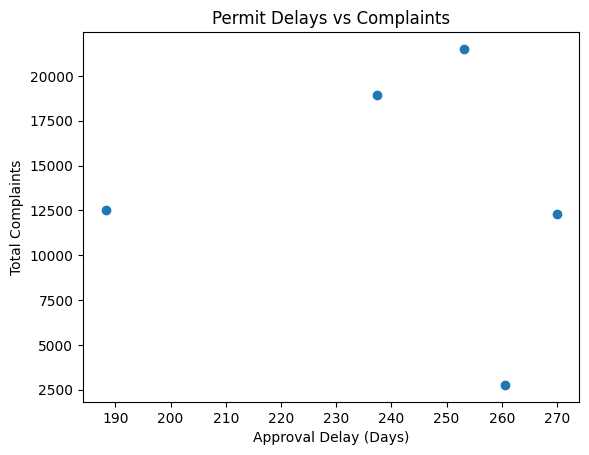

In [9]:
import matplotlib.pyplot as plt

# =========================
# DELAY VS COMPLAINTS
# =========================
plt.figure()

plt.scatter(
    final_summary['avg_days_approved_to_issued'],
    final_summary['total_complaints']
)

plt.xlabel("Approval Delay (Days)")
plt.ylabel("Total Complaints")
plt.title("Permit Delays vs Complaints")

plt.show()

In [10]:
final_summary.to_csv("final_summary.csv", index=False)